In [1]:
# Libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
# ML Models
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR

In [3]:
# Import Dataset
df = pd.read_csv('./dataset.csv')

In [4]:
df = df.apply(lambda x: x.str.strip() if x.dtype == "object" else x)

# Define categorical mappings
ordinal_mappings = {
    'Income': ['Low (Below 15,000)', 'Lower middle (15,000-30,000)', 'Upper middle (30,000-50,000)', 'High (Above 50,000)'],
    'Hometown': ['Village', 'City'],
    'Preparation': ['0-1 Hour', '2-3 Hours', 'More than 3 Hours'],
    'Gaming': ['0-1 Hour', '2-3 Hours', 'More than 3 Hours'],
    'Attendance': ['Below 40%', '40%-59%', '60%-79%', '80%-100%'],
    'Semester': ['2nd', '3rd', '4th', '5th', '6th', '7th', '8th', '9th', '10th', '11th', '12th'],
    'Job': ['No', 'Yes'],
    'Extra': ['No', 'Yes']
}

# Apply ordinal encoding
for column, categories in ordinal_mappings.items():
    df[column] = OrdinalEncoder(categories=[categories]).fit_transform(df[[column]])

In [5]:
# Function for OneHotEncoding
def one_hot_encode(df, columns):
    encoder = OneHotEncoder(sparse_output=False)
    encoded = encoder.fit_transform(df[columns])
    df_encoded = pd.DataFrame(encoded, columns=encoder.get_feature_names_out(columns))
    return pd.concat([df.drop(columns, axis=1), df_encoded], axis=1)

# Apply OneHotEncoding to 'Department' and 'Gender'
df = one_hot_encode(df, ['Department', 'Gender'])

In [6]:
# Define target and features
X = df.drop(columns=['Overall'])
y = df['Overall']
X_n = X.drop(columns=['Income', 'Hometown', 'Job'])

# Set correlation threshold
threshold = 0

# Calculate Pearson correlation with target variable (y)
correlation = X.corrwith(y).abs()

# Identify columns to drop for X, keeping specific features
columns_to_keep_X = {'Income', 'Hometown', 'Job'}
columns_to_drop_X = [col for col in correlation[correlation < threshold].index if col not in columns_to_keep_X]
X = X.drop(columns=columns_to_drop_X)

# Identify columns to drop for X_n (excluding specified features)
columns_to_drop_X_n = [col for col in correlation[correlation < threshold].index if col not in columns_to_keep_X]
X_n = X_n.drop(columns=columns_to_drop_X_n)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train_n, X_test_n, y_train_n, y_test_n = train_test_split(X_n, y, test_size=0.2, random_state=42)


In [7]:
# ----------------------------------------------------------------------------------------------------
# Model Comparison: With SES
# ----------------------------------------------------------------------------------------------------

In [8]:
# Initialize the model
model = LinearRegression()

# Fit the model to the training data
model.fit(X_train, y_train)

# Make predictions on the test data
y_pred = model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
LR_rmse = round(np.sqrt(mse), 3)
LR_r2 = round(r2_score(y_test, y_pred), 3)

# Print the results
print("Linear Regression with SES")
print(f"Root Mean Squared Error: {LR_rmse}")
print(f"R-squared: {LR_r2}")

Linear Regression with SES
Root Mean Squared Error: 0.232
R-squared: 0.856


In [9]:
model = DecisionTreeRegressor(random_state=42)

# Fit the model to the training data
model.fit(X_train, y_train)

# Make predictions on the test data
y_pred = model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
DT_rmse = round(np.sqrt(mse), 3)
DT_r2 = round(r2_score(y_test, y_pred), 3)

# Print the results
print("Decision Tree with SES")
print(f"Root Mean Squared Error: {DT_rmse}")
print(f"R-squared: {DT_r2}")

Decision Tree with SES
Root Mean Squared Error: 0.231
R-squared: 0.857


In [10]:
model = RandomForestRegressor(random_state=42)

# Fit the model to the training data
model.fit(X_train, y_train)

# Make predictions on the test data
y_pred = model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
RF_rmse = round(np.sqrt(mse), 3)
RF_r2 = round(r2_score(y_test, y_pred), 3)

# Print the results
print("Random Forest with SES")
print(f"Root Mean Squared Error: {RF_rmse}")
print(f"R-squared: {RF_r2}")

Random Forest with SES
Root Mean Squared Error: 0.168
R-squared: 0.925


In [11]:
model = SVR()

# Fit the model to the training data
model.fit(X_train, y_train)

# Make predictions on the test data
y_pred = model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
SVM_rmse = round(np.sqrt(mse), 3)
SVM_r2 = round(r2_score(y_test, y_pred), 3)

# Print the results
print("Support Vector Machine with SES")
print(f"Root Mean Squared Error: {SVM_rmse}")
print(f"R-squared: {SVM_r2}")

Support Vector Machine with SES
Root Mean Squared Error: 0.213
R-squared: 0.879


In [12]:
# ----------------------------------------------------------------------------------------------------
# Model Comparison: Without SES
# ----------------------------------------------------------------------------------------------------

In [13]:
# Initialize the model
model = LinearRegression()

# Fit the model to the training data
model.fit(X_train_n, y_train_n)

# Make predictions on the test data
y_pred = model.predict(X_test_n)

# Evaluate the model
mse = mean_squared_error(y_test_n, y_pred)
LR_rmse_n = round(np.sqrt(mse), 3)
LR_r2_n = round(r2_score(y_test_n, y_pred), 3)

# Print the results
print("Linear Regression without SES")
print(f"Root Mean Squared Error: {LR_rmse_n}")
print(f"R-squared: {LR_r2_n}")

Linear Regression without SES
Root Mean Squared Error: 0.202
R-squared: 0.891


In [14]:
model = DecisionTreeRegressor(random_state=42)

# Fit the model to the training data
model.fit(X_train_n, y_train_n)

# Make predictions on the test data
y_pred = model.predict(X_test_n)

# Evaluate the model
mse = mean_squared_error(y_test_n, y_pred)
DT_rmse_n = round(np.sqrt(mse), 3)
DT_r2_n = round(r2_score(y_test_n, y_pred), 3)

# Print the results
print("Decision Tree without SES")
print(f"Root Mean Squared Error: {DT_rmse_n}")
print(f"R-squared: {DT_r2_n}")

Decision Tree without SES
Root Mean Squared Error: 0.173
R-squared: 0.92


In [15]:
model = RandomForestRegressor(random_state=42)

# Fit the model to the training data
model.fit(X_train_n, y_train_n)

# Make predictions on the test data
y_pred = model.predict(X_test_n)

# Evaluate the model
mse = mean_squared_error(y_test_n, y_pred)
RF_rmse_n = round(np.sqrt(mse), 3)
RF_r2_n = round(r2_score(y_test_n, y_pred), 3)

# Print the results
print("Random Forest without SES")
print(f"Root Mean Squared Error: {RF_rmse_n}")
print(f"R-squared: {RF_r2_n}")

Random Forest without SES
Root Mean Squared Error: 0.164
R-squared: 0.928


In [16]:
model = SVR()

# Fit the model to the training data
model.fit(X_train_n, y_train_n)

# Make predictions on the test data
y_pred = model.predict(X_test_n)

# Evaluate the model
mse = mean_squared_error(y_test_n, y_pred)
SVM_rmse_n = round(np.sqrt(mse), 3)
SVM_r2_n = round(r2_score(y_test_n, y_pred), 3)

# Print the results
print("Support Vector Machine without SES")
print(f"Root Mean Squared Error: {SVM_rmse_n}")
print(f"R-squared: {SVM_r2_n}")

Support Vector Machine without SES
Root Mean Squared Error: 0.214
R-squared: 0.877


In [17]:
# ----------------------------------------------------------------------------------------------------
# Comparison
# ----------------------------------------------------------------------------------------------------

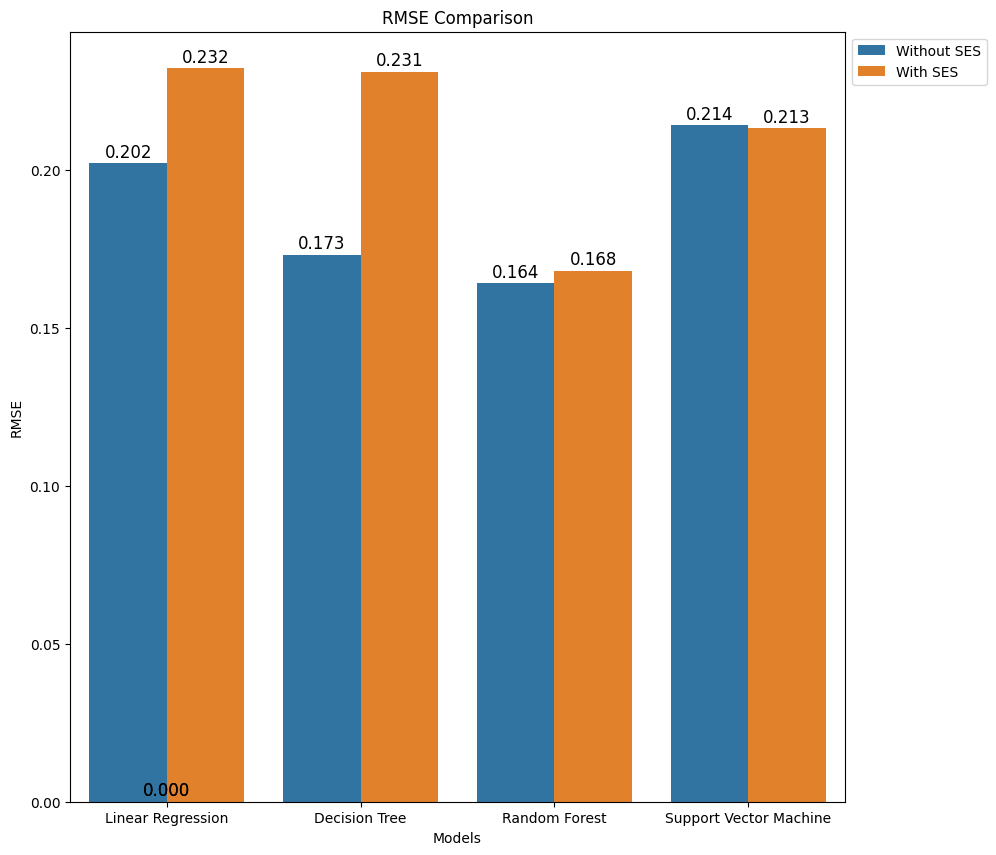

In [18]:
# Data
groups = ['Linear Regression', 'Decision Tree', 'Random Forest', 'Support Vector Machine']
values1 = [LR_rmse_n, DT_rmse_n, RF_rmse_n, SVM_rmse_n]
values2 = [LR_rmse, DT_rmse, RF_rmse, SVM_rmse]

# Create a DataFrame
graph_df = pd.DataFrame({
    'Group': groups * 2,
    'Value': values1 + values2,
    'Type': ['Without SES'] * len(groups) + ['With SES'] * len(groups)
})

# Create the bar plot with default Seaborn colors (blue and orange)
plt.figure(figsize=(10, 10))
sns.barplot(x='Group', y='Value', hue='Type', data=graph_df)

# Add value annotations with three decimal places
for p in plt.gca().patches:
    plt.gca().annotate(f'{p.get_height():.3f}',  # Change to 3 decimal places
                       (p.get_x() + p.get_width() / 2., p.get_height()), 
                       ha='center', va='center', 
                       fontsize=12, color='black', 
                       xytext=(0, 8), textcoords='offset points')

# Title and labels
plt.title('RMSE Comparison')
plt.xlabel('Models')
plt.ylabel('RMSE')

# Move the legend outside the plot to the right
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))

# Show the plot
plt.show()

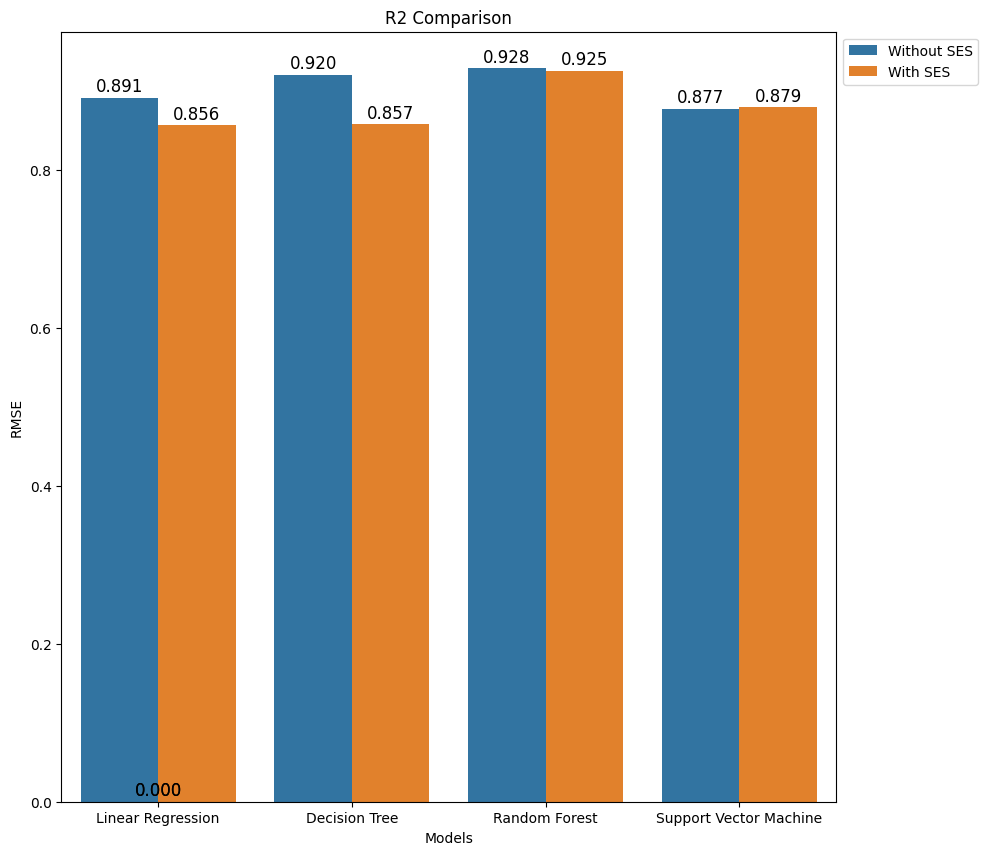

In [19]:
# Data
groups = ['Linear Regression', 'Decision Tree', 'Random Forest', 'Support Vector Machine']
values1 = [LR_r2_n, DT_r2_n, RF_r2_n, SVM_r2_n]
values2 = [LR_r2, DT_r2, RF_r2, SVM_r2]

# Create a DataFrame
graph_df = pd.DataFrame({
    'Group': groups * 2,
    'Value': values1 + values2,
    'Type': ['Without SES'] * len(groups) + ['With SES'] * len(groups)
})

# Create the bar plot with default Seaborn colors (blue and orange)
plt.figure(figsize=(10, 10))
sns.barplot(x='Group', y='Value', hue='Type', data=graph_df)

# Add value annotations with three decimal places
for p in plt.gca().patches:
    plt.gca().annotate(f'{p.get_height():.3f}',  # Change to 3 decimal places
                       (p.get_x() + p.get_width() / 2., p.get_height()), 
                       ha='center', va='center', 
                       fontsize=12, color='black', 
                       xytext=(0, 8), textcoords='offset points')

# Title and labels
plt.title('R2 Comparison')
plt.xlabel('Models')
plt.ylabel('RMSE')

# Move the legend outside the plot to the right
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))

# Show the plot
plt.show()